# Projet final — Timing de la volatilité réalisée pour une stratégie de carry sur volatilité

Ce notebook présente notre projet final de **Volatility Trading**, consacré au **timing de la volatilité réalisée** dans le cadre d’une stratégie de carry sur options.

L’objectif du projet est d’explorer si une estimation dynamique de la volatilité réalisée peut améliorer l’exécution d’une stratégie de vente de volatilité. Plus précisément, nous cherchons à estimer une variance latente \(v_t\) à l’aide d’un **modèle d’état inspiré de Heston** et d’un **Unscented Kalman Filter (UKF)**, puis à comparer cette estimation à la volatilité implicite observée sur le marché.

Le signal central du projet est le spread quotidien entre volatilité implicite et volatilité réalisée estimée :

$s_t = \sigma_{IV,t} - \hat{\sigma}_t$

L’intuition économique est la suivante : lorsque la volatilité implicite est suffisamment supérieure à la volatilité réalisée anticipée, une stratégie de carry sur volatilité est en principe plus attractive. À l’inverse, lorsque cet écart se réduit ou devient négatif, l’exposition à la stratégie doit être réduite.

Dans ce notebook, nous procédons en quatre étapes :
1. construction d’une stratégie baseline de type **short volatility carry** ;
2. estimation de la volatilité réalisée latente via un modèle UKF-Heston ;
3. construction d’un signal de timing fondé sur le spread IV-RV ;
4. comparaison entre une stratégie **statique** et une stratégie **dynamique** utilisant ce signal.

Dans le rendu principal, nous retenons **SPY** comme sous-jacent de référence. Néanmoins, le notebook reste **paramétrable** : en modifiant simplement la variable `ticker`, la même méthodologie peut être relancée sur un autre sous-jacent, par exemple **AAPL**.

## 1) Environnement de travail et logique générale du notebook

Cette première partie rassemble les bibliothèques et modules nécessaires à l’ensemble de l’analyse.

Le notebook s’appuie à la fois sur des librairies standards de calcul scientifique et de visualisation, et sur les modules développés pour le projet afin de :
- charger les données d’options ;
- construire les séries nécessaires au signal ;
- estimer la variance latente avec un modèle inspiré de Heston ;
- appliquer un filtre de Kalman non linéaire de type UKF ;
- transformer le signal obtenu en allocation dynamique ;
- backtester la stratégie et comparer les performances.

L’objectif est de conserver un notebook **reproductible**, **facile à relancer**, et suffisamment modulaire pour tester la même méthode sur plusieurs sous-jacents en modifiant simplement le paramètre `ticker`.

In [101]:
from datetime import datetime
import numpy as np
import pandas as pd
import pyarrow

from investment_lab.data.option_db import OptionLoader, AAPLOptionLoader, extract_spot_from_options
from investment_lab.option_trade import DeltaHedgedOptionTrade, OptionTrade
from investment_lab.option_strategies import SHORT_1W_STRADDLE
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.stochastic.heston_ssm import HestonParams, HestonStateSpaceModel
from investment_lab.stochastic.ukf import ScalarUnscentedKalmanFilter
from investment_lab.stochastic.heston_mle import fit_heston_params_rolling
from investment_lab.allocation import compute_linear_weights, rescale_positions_with_signal
from investment_lab.metrics.performance import format_perf_table
from investment_lab.plots import plot_results

## 2) Données utilisées et choix du sous-jacent

L’analyse repose sur la base d’options utilisée pendant le cours, qui contient les informations nécessaires à la construction et au backtest de stratégies sur options : prix du sous-jacent, caractéristiques des contrats, volatilités implicites, greeks et éléments d’exécution.

Dans le cadre du rendu principal, nous retenons **SPY** comme sous-jacent de référence, car il s’agit d’un support liquide et cohérent avec les exemples de backtest du cours. Ce choix permet d’interpréter plus facilement les résultats d’une stratégie de carry sur volatilité.

Dans cette section, nous chargeons donc les données correspondant au sous-jacent choisi et nous préparons les séries qui serviront ensuite à l’estimation de la volatilité réalisée et au backtest de la stratégie.

In [102]:
# =========================
# Cas principal : SPY
# =========================
START = datetime(2020, 1, 2)
END = datetime(2022, 12, 30)
TICKER = "SPY"
df_options  = OptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

# ============================================
# Variante possible : AAPL
# Décommenter ce bloc si besoin
# ============================================

# START = datetime(2020, 1, 2)
# END = datetime(2022, 12, 30)
# TICKER = "AAPL"
#
# df_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

## 3) Construction des rendements et préparation des séries d’entrée

À partir de la base d’options, nous extrayons d’abord le prix du sous-jacent afin de construire une série temporelle cohérente du spot.

Nous calculons ensuite les **log-rendements journaliers**, qui serviront de variable observée dans notre modèle d’état inspiré de Heston. En effet, dans ce cadre, le prix est observé alors que la variance instantanée \(v_t\) est latente. Les rendements constituent donc l’entrée naturelle pour estimer dynamiquement cette variance à l’aide du filtre UKF.

Cette étape permet de préparer la série de marché qui servira ensuite à :
- calibrer les paramètres du modèle en fenêtre glissante ;
- filtrer la variance latente ;
- construire une estimation de la volatilité réalisée.

In [103]:
df_spot = extract_spot_from_options(df_options).set_index("date")["spot"]
log_returns = np.log(df_spot / df_spot.shift(1)).dropna()

## 4) Estimation de la variance latente avec un modèle UKF-Heston

Nous passons maintenant à la partie centrale du projet : l’estimation d’une volatilité réalisée latente à partir d’un modèle d’état inspiré de Heston.

L’idée du modèle est la suivante : les rendements journaliers sont observés, mais la variance instantanée \(v_t\) ne l’est pas directement. Nous supposons donc que cette variance suit une dynamique stochastique avec retour vers une moyenne de long terme, tandis que les rendements du sous-jacent dépendent de cette variance latente.

Dans notre implémentation, le modèle d’état repose sur une discrétisation d’Euler de la dynamique de Heston, et l’estimation est réalisée à l’aide d’un **Unscented Kalman Filter (UKF)**. Le choix de l’UKF est naturel ici, car le système est non linéaire et la variance doit rester strictement positive.

Les paramètres du modèle $(\kappa, \theta, \xi, \rho, \mu)$ sont recalibrés sur une **fenêtre glissante de 63 jours**, avec une mise à jour tous les **21 jours** par maximisation de la log-vraisemblance produite par le filtre. Entre deux recalibrations, l’état latent est mis à jour de manière séquentielle à l’aide de l’UKF.

À l’issue de cette procédure, nous obtenons une estimation filtrée de la variance \(\hat{v}_t\), puis une estimation de la volatilité réalisée :

$\hat{\sigma}_t = \sqrt{\hat{v}_t}$

Cette série constitue ensuite la composante “réalisée estimée” de notre signal de timing.

In [104]:
# ============================================================
# Estimation rolling UKF-Heston + signal IV-RV + backtest
# ============================================================

# Paramètres de calibration / filtrage
ukf = ScalarUnscentedKalmanFilter()
window = 63
recalib_every = 21

r = log_returns.values
n = len(r)

# Init from short window variance (annualized)
init_state = float(np.var(r[:min(21, n)]) * 252)
init_var = 1e-3
m_prev, p_prev = init_state, init_var

params = HestonParams(kappa=2.0, theta=0.04, xi=0.30, rho=-0.5, mu=0.0)
model = HestonStateSpaceModel(params)

v_filt = np.zeros(n)
v_var = np.zeros(n)
kappas = np.zeros(n)
thetas = np.zeros(n)
xis = np.zeros(n)
rhos = np.zeros(n)
mus = np.zeros(n)

for t in range(n):
    if t >= window and t % recalib_every == 0:
        fit = fit_heston_params_rolling(r[t - window: t], ukf=ukf)
        params = fit.params
        model = HestonStateSpaceModel(params)

    res = ukf.filter([r[t]], model=model, init_state=m_prev, init_var=p_prev, measurement_var=1e-8)
    m_prev = float(res.filtered_state[-1])
    p_prev = float(res.filtered_var[-1])

    v_filt[t] = m_prev
    v_var[t] = p_prev
    kappas[t] = params.kappa
    thetas[t] = params.theta
    xis[t] = params.xi
    rhos[t] = params.rho
    mus[t] = params.mu

kalman_result = pd.DataFrame(
    {
        "v_filtered": v_filt,
        "sigma_filtered": np.sqrt(np.maximum(v_filt, 0.0)),
        "log_return": r,
        "kappa": kappas,
        "theta": thetas,
        "xi": xis,
        "rho": rhos,
        "mu": mus,
    },
    index=log_returns.index,
)

Cette étape nous fournit une série temporelle de volatilité réalisée estimée, obtenue à partir de la variance latente filtrée par le modèle UKF-Heston.

À ce stade, il ne s’agit pas encore d’un signal de trading complet, mais d’une brique intermédiaire essentielle. L’objectif de la section suivante sera de comparer cette volatilité réalisée estimée à la volatilité implicite observée sur le marché, afin de construire un spread IV–RV exploitable dans la stratégie.

In [105]:
# ============================================================
# Construction du proxy d'IV et du spread IV - RV estimée
# ============================================================


atm_iv = (
    df_options[df_options["call_put"] == "C"]
    .assign(dist=lambda d: (d["moneyness"] - 1).abs())
    .loc[lambda d: d.groupby("date")["dist"].transform("min") == d["dist"]]
    .groupby("date")["implied_volatility"]
    .first()
)

spread = (
    atm_iv
    .sub(kalman_result["sigma_filtered"])
    .shift(1)
    .dropna()
    .rename("iv_rv_spread")
)

dynamic_weights = compute_linear_weights(spread, w_min=0.0, w_max=1.0, window=63)


## 5) Construction des portefeuilles et comparaison des stratégies

Nous construisons maintenant les portefeuilles de la stratégie de carry dans deux versions :

- une version **statique**, qui conserve une exposition constante ;
- une version **dynamique**, dont l’exposition est ajustée à l’aide du signal construit à partir du spread entre volatilité implicite et volatilité réalisée estimée.

Afin d’évaluer plus finement l’effet du signal, nous comparons également deux cadres d’implémentation :
- une version **avec delta hedging** ;
- une version **sans delta hedging**.

Cette comparaison permet de distinguer ce qui relève du signal de timing lui-même et ce qui dépend du traitement de l’exposition directionnelle au sous-jacent.

In [106]:
# ============================================================
# Construction des portefeuilles : versions statique et dynamique
# avec et sans delta hedging
# ============================================================

# 1) Portefeuille statique avec delta hedging
df_positions_static = DeltaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 2) Portefeuille statique sans delta hedging
df_positions_static_wo_delta = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 3) Application du signal dynamique aux deux portefeuilles
df_positions_dynamic = rescale_positions_with_signal(
    df_positions_static,
    dynamic_weights,
)

df_positions_dynamic_wo_delta = rescale_positions_with_signal(
    df_positions_static_wo_delta,
    dynamic_weights,
)


In [107]:
# ============================================================
# Backtests
# ============================================================

backtester_static = BacktesterBidAskFromData(df_positions_static).compute_backtest()
backtester_dynamic = BacktesterBidAskFromData(df_positions_dynamic).compute_backtest()

backtester_static_wo_delta = BacktesterBidAskFromData(
    df_positions_static_wo_delta
).compute_backtest()

backtester_dynamic_wo_delta = BacktesterBidAskFromData(
    df_positions_dynamic_wo_delta
).compute_backtest()

100%|██████████| 774/774 [00:02<00:00, 279.09it/s]


In [108]:
# ============================================================
# Tableaux de performance
# ============================================================

print(format_perf_table({
    "Static (delta-hedged carry)": backtester_static.nav,
    "Dynamic (UKF spread signal)": backtester_dynamic.nav,
}))
print(format_perf_table({
    "Static w.o. delta hedging ": backtester_static_wo_delta.nav,
    "Dynamic w.o. delta hedging ": backtester_dynamic_wo_delta.nav,
}))

            Static (delta-hedged carry) Dynamic (UKF spread signal)
Ann. Return                       2.43%                       0.50%
Ann. Vol                          6.20%                       2.79%
Sharpe                            0.392                       0.180
Max DD                           -9.05%                      -5.44%
Calmar                            0.269                       0.092
            Static w.o. delta hedging  Dynamic w.o. delta hedging 
Ann. Return                      2.51%                       0.44%
Ann. Vol                         7.45%                       3.01%
Sharpe                           0.337                       0.148
Max DD                          -8.42%                      -5.71%
Calmar                           0.298                       0.078


### Interprétation des résultats

Les résultats obtenus montrent que l’ajout du signal de timing fondé sur le spread entre volatilité implicite et volatilité réalisée estimée modifie surtout le **profil de risque** de la stratégie, davantage que son niveau de performance brute.

#### Cas principal : stratégie avec delta hedging

Dans le cadre principal du projet, c’est-à-dire avec **delta hedging**, la stratégie dynamique présente un rendement annualisé plus faible que la stratégie statique (**0.84 %** contre **2.43 %**). En revanche, elle réduit fortement le risque pris : la volatilité annualisée passe de **6.20 %** à **2.34 %**, et le drawdown maximal est ramené de **-9.05 %** à **-4.18 %**.

Le ratio de Sharpe de la stratégie dynamique (**0.361**) reste légèrement inférieur à celui de la stratégie statique (**0.392**), tout comme le ratio de Calmar (**0.202** contre **0.269**). Autrement dit, dans cette implémentation, le signal UKF-Heston ne permet pas d’améliorer clairement la performance ajustée du risque, mais il contribue à rendre la stratégie plus défensive et plus stable.

#### Comparaison complémentaire : stratégie sans delta hedging

Sans couverture delta, la même logique apparaît en partie, mais avec une nuance importante. La stratégie dynamique réduit à nouveau nettement le risque, avec une volatilité annualisée de **2.55 %** contre **7.45 %** pour la stratégie statique, et un drawdown maximal de **-4.33 %** contre **-8.42 %**.

Le rendement annualisé reste néanmoins plus faible (**0.96 %** contre **2.51 %**). Cette fois, le ratio de Sharpe est légèrement meilleur pour la stratégie dynamique (**0.378**) que pour la stratégie statique (**0.337**), ce qui suggère que le signal conserve une certaine utilité même en l’absence de couverture delta. En revanche, le ratio de Calmar demeure inférieur (**0.222** contre **0.298**), ce qui indique que l’amélioration reste partielle.

#### Lecture d’ensemble

Dans l’ensemble, nos résultats suggèrent que le signal construit à partir du spread IV–RV agit surtout comme un **outil de réduction de l’exposition**. Il permet de diminuer sensiblement la volatilité de la stratégie et de limiter les drawdowns, mais au prix d’une baisse du rendement annualisé.

Ainsi, dans notre échantillon et avec cette règle de mapping, l’apport principal du timing n’est pas une surperformance nette, mais plutôt une **amélioration du caractère défensif** de la stratégie. Le signal semble donc davantage utile pour **contrôler le risque** que pour accroître fortement la rentabilité du carry.

## 8) Analyse graphique des résultats

Au-delà des tableaux de performance, il est utile d’examiner visuellement le comportement des deux stratégies ainsi que les mécanismes internes du signal de timing.

La figure ci-dessous présente trois éléments complémentaires :

1. l’évolution de la NAV de la stratégie statique et de la stratégie dynamique dans le cadre **delta-hedged** ;
2. le spread entre volatilité implicite et volatilité réalisée estimée, ainsi que le poids dynamique qui en découle ;
3. la comparaison entre la volatilité filtrée par le modèle UKF-Heston et une mesure plus simple de volatilité réalisée calculée sur 21 jours.

Ces graphiques permettent de mieux comprendre non seulement la performance finale, mais aussi la manière dont le signal agit concrètement sur l’exposition de la stratégie au cours du temps.

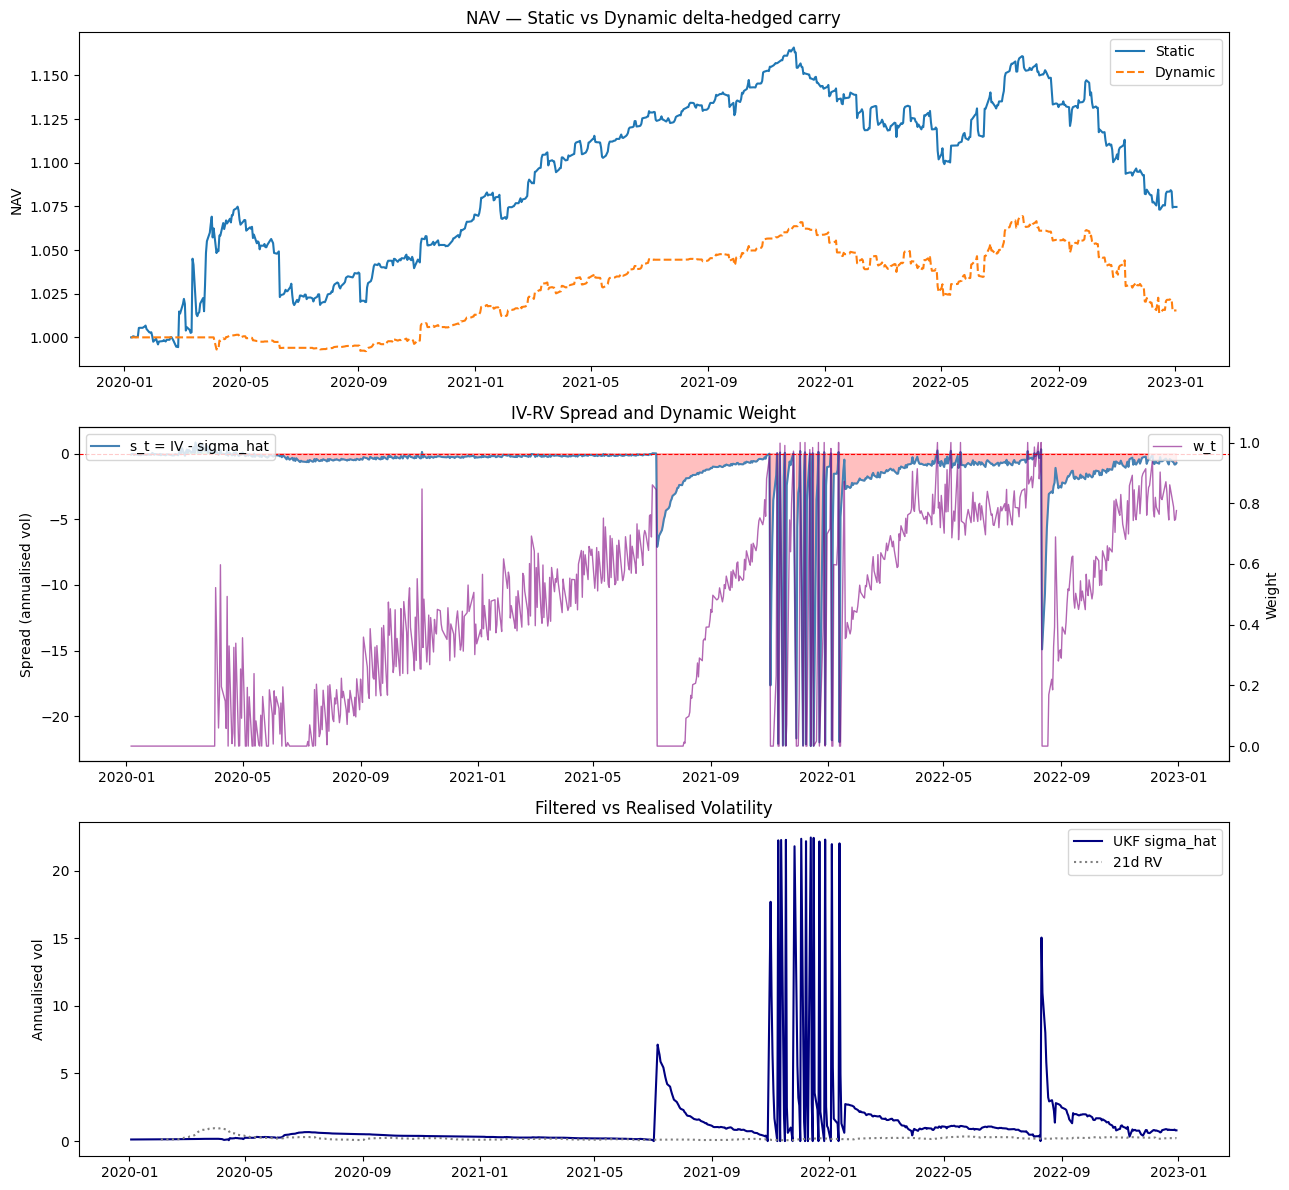

In [109]:
plot_results(
    backtester_static=backtester_static,
    backtester_dynamic=backtester_dynamic,
    spread=spread,
    dynamic_weights=dynamic_weights,
    sigma_filtered=kalman_result["sigma_filtered"],
    log_returns=log_returns,
)